In [1]:
import pandas as pd
import numpy as np

import math

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import src.data.dataprep as prep

In [2]:
nl_data_list = []

for i in range(27):
    # Import the base data and resample it from 5 minutes to hourly
    nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(i) + '.parquet', 'h')
    # Include net load for cost calculations
    nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
    # Import a price profile and merge it with the consumption data
    nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
    nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)
    # calculate the cost to be a positive net load x offtake minus a negative net load x injection
    nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)
    
    nl_data_list.append(nl_data)

In [3]:
def estimate_kwp(data, column='solar_energy', PR=0.8, PSH=5):
    """
    Estimate the kWp of a PV system from hourly PV generation data.
    
    Parameters:
        nl_data (pd.DataFrame): DataFrame containing hourly PV generation data.
        column (str): Name of the column with PV generation data.
        PR (float): Performance ratio (default = 0.8).
        PSH (float): Peak Sun Hours per day (default = 5).
        
    Returns:
        float: Estimated kWp of the PV system.
    """
    # Find the peak hourly generation (highest recorded kW output)
    peak_kw = data[column].max()

    # Group data by day and calculate daily energy generation (kWh)
    daily_generation = data[column].resample('D').sum()

    # Compute the average daily generation across all available days
    avg_daily_kwh = daily_generation.mean()

    # Estimate kWp using the average daily generation and PSH
    estimated_kwp = avg_daily_kwh / (PSH * PR)

    return peak_kw, estimated_kwp

In [12]:
solar_energy = []
max_load = []
jolien_pv = []
jolien_load = []
pv_to_consumption = []

for i in range(len(nl_data_list)):
    solar_energy.append(nl_data_list[i]['solar_energy'].max())
    max_load.append(math.floor(nl_data_list[i]['load'].resample('D').sum().max()))
    _, estimated_kwp = estimate_kwp(nl_data_list[i])
    jolien_pv.append(estimated_kwp * 1.04)
    jolien_load.append(math.floor(nl_data_list[i]['load'].resample('YE').sum().max() * 1.17 / 1000))
    pv_to_consumption.append(estimated_kwp / (nl_data_list[i]['load'].resample('YE').sum().max() / 1000))
                       
solar_energy = np.array(solar_energy)
max_load = np.array(max_load)
jolien_pv = np.array(jolien_pv)
jolien_load = np.array(jolien_load)
pv_to_consumption = np.array(pv_to_consumption)

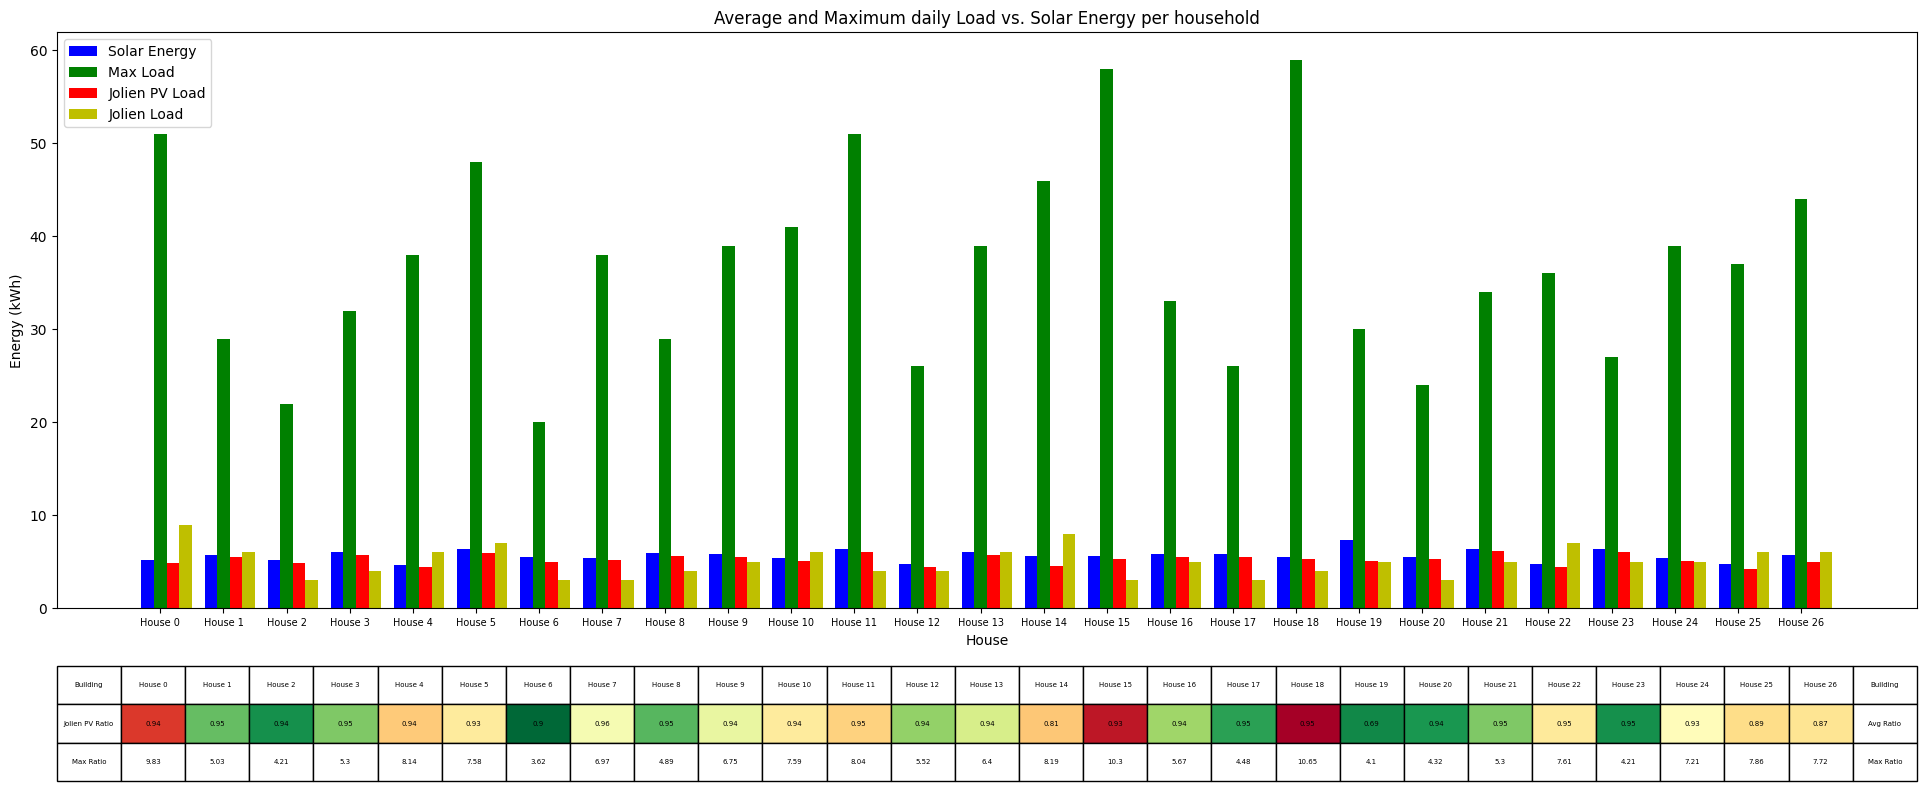

In [13]:
# Compute ratio (handling division by zero)
max_ratio = np.round(max_load / solar_energy, 2)
jolien_pv_ratio = np.round(jolien_pv / solar_energy, 2)
jolien_ratio = np.round(jolien_load / solar_energy, 2)

# X locations for the clusters
x = np.arange(len(solar_energy)) * 1.5  
width = 0.3  

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(24, 12))

# Plot bar charts
bars1 = ax1.bar(x - width, solar_energy, width, color='b', label='Solar Energy')
bars2 = ax1.bar(x, max_load, width, color='g', label='Max Load')
bars3 = ax1.bar(x+width, jolien_pv, width, color='r', label='Jolien PV Load')
bars4 = ax1.bar(x+2*width, jolien_load, width, color='y', label='Jolien Load')

# Labels and title
ax1.set_xlabel("House")
ax1.set_ylabel("Energy (kWh)")
plt.title("Average and Maximum daily Load vs. Solar Energy per household")

# Set x-ticks to align with clusters
ax1.set_xticks(x)
ax1.set_xticklabels([f"House {i}" for i in range(len(solar_energy))], fontsize=7)

# Legend
ax1.legend(loc="upper left")

# Color scale (Red → Green) for avg ratio
norm = plt.Normalize(vmin=np.min(max_ratio), vmax=np.max(max_ratio))
cmap = plt.get_cmap("RdYlGn_r")  # Reverse RdYlGn
colors = [mcolors.to_hex(cmap(norm(value))) for value in max_ratio]

# Create a table with row names + ratios
table_data = [
    ["Building"] + [f"House {i}" for i in range(len(max_ratio))] + ["Building"],
    ["Jolien PV Ratio"] + list(jolien_pv_ratio.astype(str)) + ["Avg Ratio"],
    ["Max Ratio"] + list(max_ratio.astype(str)) + ["Max Ratio"]
]

# Create the table
table = ax1.table(cellText=table_data,
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0, -0.3, 1, 0.2])  # Adjust position & size

# Apply colors to the avg ratio values (skipping the first column)
for i in range(1, len(max_ratio) + 1):  
    table._cells[(1, i)].set_facecolor(colors[i - 1])

# Adjust layout to fit the table
plt.subplots_adjust(bottom=0.4)

# Show plot
plt.show()